In [2]:
#THINGS TO DO

#Convert samples to 2d numpy array? or does tensorflow take dataframes?

#NON CONSECUTIVE TRENDS - SO IF AFTER 10 STICKS, IT IS A GAIN, THAT WOULD BE UP TREND DESPITE CANDLES
    #Additional TARGETS
    # CAN BE THAT CONSECUTIVE AND NON CONSECUTIVE OVERLAP

#DEVELOP MISSING STICKS WORKAROUND
    #LIENAR REGRESSION
    #MEAN OF STICK i - 1 and STICK i + 1

#EVENTUALLY - PULL IN ALL RAW DATA, TRANSITION BACK TO 5MINUTE STICKS, AND INCLUDE PREMARKET 
    #(WE DONT SHOP IN PRE MARKET SO TARGET WOULD BE NO TREND)

#EVENTUALLY WANT PREVIOUS DAY CLOSE AND PREVIOUS DAY OPEN
    # CAN PULL FROM YFINANCE AND MERGE WITH OUR RAW DATA FOR THIS

#ADD VOLUME, TRADE_COUNT, VWAP BACK IN
    #INCLUDE IN PLOTS


In [3]:
#import relevent libraries
#basic
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

#Read in dataframe 
    #if file is large this can be time consuming to repeat
    #only call this once and create a deep copy to work with
# df_original = pd.read_csv('AMZN_100_days_30_minute_candles.csv')

In [4]:
csv_files = [
    'AMZN_100_days_30_minute_candles.csv',
    'GOOG_100_days_30_minute_candles.csv',
    'JPM_100_days_30_minute_candles.csv',
    'MSFT_100_days_30_minute_candles.csv',
    'TSLA_100_days_30_minute_candles.csv',
    'UNH_100_days_30_minute_candles.csv',
    'XOM_100_days_30_minute_candles.csv',
    'GM_100_days_30_minute_candles.csv',
    'BA_100_days_30_minute_candles.csv'
]

In [5]:
# df = df_original.copy(deep=True)
# df

In [6]:
def process_symbol_data(df_original):
    df = df_original.copy(deep=True)
    df['utc_datetime'] = pd.to_datetime(df.timestamp,   errors='coerce')
    df['date'] = df.utc_datetime.dt.date
    #df['month'] = df.utc_datetime.dt.month
    df['day'] = df.utc_datetime.dt.day
    df['time'] = df.utc_datetime.dt.time
    df['day_of_week'] = df.utc_datetime.dt.dayofweek
    df['hour'] = df.utc_datetime.dt.hour
    df['minute'] = df.utc_datetime.dt.minute
    df.drop(columns=['utc_datetime','timestamp'], inplace=True)
    
    df.sort_values(by =['date', 'time'], ascending=[False, True],inplace=True)

    start_time = dt.time(9,30,0)
    stop_time = dt.time(16,0,0)

    #drop time slots we dont care about
    df = df[df.time >=start_time]
    df = df[df.time <=stop_time]
    #df.dropna(inplace=True)

    #count number of sticks
    df['number_sticks_per_day'] = df.groupby('date')['date'].transform('count')

    #16-6 = 10 hours * 12 = 120
    #guarantee days are uniform
    df =df[df.number_sticks_per_day >= 14]
    #print(df.number_sticks_per_day.unique())
    df.dropna(inplace=True)

    #Drop any desireable dates from training set
    # df = df.where(df.date.astype(str)!='2026-05-06')

    series_unique_dates = df.date.unique()
    # print(len(series_unique_dates))


    df.drop(columns=['number_sticks_per_day'],inplace=True)
    # df.head()
    return df, series_unique_dates

# df_original = pd.read_csv('AMZN_100_days_30_minute_candles.csv')
# process_symbol_data(df_original)

In [7]:
def load_all_symbol_data():
    dataframes = {}
    for file_path in csv_files:
        df_original = pd.read_csv(file_path)
        symbol = df_original['symbol'].iloc[0]  # stock symbol
        df, series_unique_dates = process_symbol_data(df_original)
        dataframes[symbol] = (df, series_unique_dates)
    #     for date in series_unique_dates:
    #         df_date = df[df['date'] == date]
    #         dataframes[f"{symbol}_{date}"] = df_date
    # combined_df = pd.concat(dataframes.values(), ignore_index=True)
    return dataframes


In [8]:
def trend_viable(min_length,min_strength,x1,x2,y1,y2):
    #is trend duration long enough
    if (x2-x1) >= min_length:
        #is trend strong enough
        slope =  (y2-y1)/(x2-x1)
        #abs of slope is magnitude
        if abs(slope) >= min_strength:
            #trend is viable
            return True
            
    return False


In [9]:
def consecutive_trend_search(series):
    up_trends = np.zeros(len(series.close),dtype=int)
    down_trends = np.zeros(len(series.close),dtype=int)

    prices = np.array(series.close)
    index = np.array(series.index)

    n=0
    direction = 0
    trend_started=False
    
    
    min_up_length = 3
    min_up_strength = 0.001*np.mean(prices)
    
    min_down_length = 3
    min_down_strength = 0.001*np.mean(prices)
    
    #uptrend
    for i in range(len(prices)-1):
        
        #2============================================
        #if trending up
        if prices[i] < prices[i + 1]:
            
            #3============================================
            #check if it was end of down run
            if trend_started and direction !=1:
            
                #4============================================
                #if it was, check if down run was a worthy trend 
                if trend_viable(min_up_length,min_up_strength,n,i,prices[n],prices[i]):
                
                    #if so push trend list into up trend list
                    up_trends[n:i]=1
                    
                #4============================================
                #reset trend regardless of viability
                trend_started = False

            #3============================================
            #if first up, initiate trend
            if not trend_started:
                n=i
                trend_started=True
                direction = 1
                
        #2============================================
        #if trending down
        elif prices[i] > prices[i + 1]:

            if trend_started and direction !=-1:
                if trend_viable(min_down_length,min_down_strength,n,i,prices[n],prices[i]):
                    down_trends[n:i]=1
               
                trend_started = False
                    
            if not trend_started:
                n=i
                trend_started=True
                direction = -1
            
        #2============================================
        #if no direction, check if end of trend run
        else:
            
            if trend_started and direction ==1:
                if trend_viable(min_up_length,min_up_strength,n,i,prices[n],prices[i]):
                    up_trends[n:i]=1
                    
            if trend_started and direction ==-1:
                if trend_viable(min_down_length,min_down_strength,n,i,prices[n],prices[i]):
                    down_trends[n:i]=1
                    
            trend_started = False
    return up_trends,down_trends
                

In [10]:
#%matplotlib qt
%matplotlib inline 
def plot(stock_chart):
    
    plt.style.use('dark_background')
    fig, ax = plt.subplots(1,1,figsize=(10,10))
    ax.set_title(f"{stock_chart.symbol.iloc[0]} Stock Chart")
    
    gain_ticks = stock_chart[stock_chart.close >= stock_chart.open]
    loss_ticks = stock_chart[stock_chart.close <  stock_chart.open]
    
    gain_sticks       = gain_ticks.close - gain_ticks.open
    gain_top_wicks    = gain_ticks.high  - gain_ticks.close
    gain_bottom_wicks = gain_ticks.open  - gain_ticks.low
    
    loss_sticks       = loss_ticks.open  - loss_ticks.close
    loss_top_wicks    = loss_ticks.high  - loss_ticks.open
    loss_bottom_wicks = loss_ticks.close - loss_ticks.low
    
    gain_color = 'green'
    loss_color = 'red'
    
    stick_width = .3
    wick_width = .03
    
    ax.bar(gain_ticks.index, gain_sticks,      stick_width,bottom=gain_ticks.open,  color=gain_color)
    ax.bar(gain_ticks.index, gain_top_wicks,   wick_width, bottom=gain_ticks.close, color=gain_color)
    ax.bar(gain_ticks.index, gain_bottom_wicks,wick_width, bottom=gain_ticks.low,   color=gain_color)
    
    ax.bar(loss_ticks.index, loss_sticks,      stick_width,bottom=loss_ticks.close, color=loss_color)
    ax.bar(loss_ticks.index, loss_top_wicks,   wick_width, bottom=loss_ticks.open,  color=loss_color)
    ax.bar(loss_ticks.index, loss_bottom_wicks,wick_width, bottom=loss_ticks.low,   color=loss_color)

    down_trends = stock_chart[stock_chart.down_trend==1]
    ax.plot(down_trends.index,down_trends.down_trend*down_trends.close,color='blue',linewidth = 5,alpha = 1)
    
    uptrends = stock_chart[stock_chart.up_trend==1]
    ax.plot(uptrends.index,uptrends.up_trend*uptrends.close,color='yellow',linewidth = 5,alpha = 1)
    
    ax.set_xticks(stock_chart.index,stock_chart.time,rotation = 'vertical')

    stock_chart = stock_chart[stock_chart.low>0]
    ax.set_ylim(np.min(stock_chart.low),np.max(stock_chart.high))
    
    plt.show()

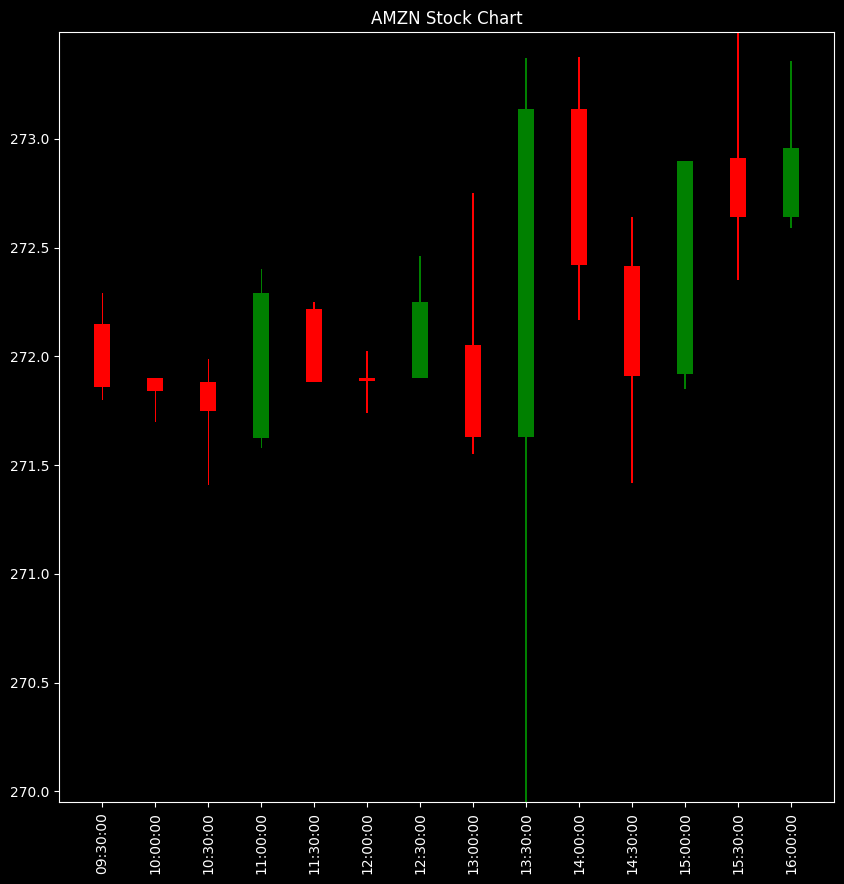

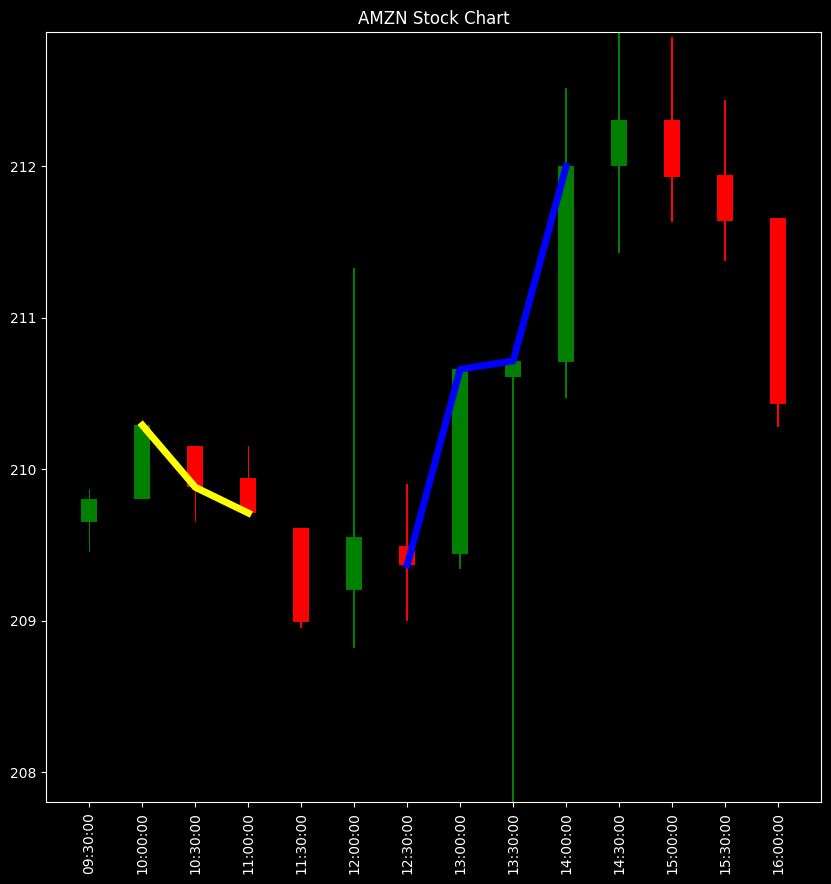

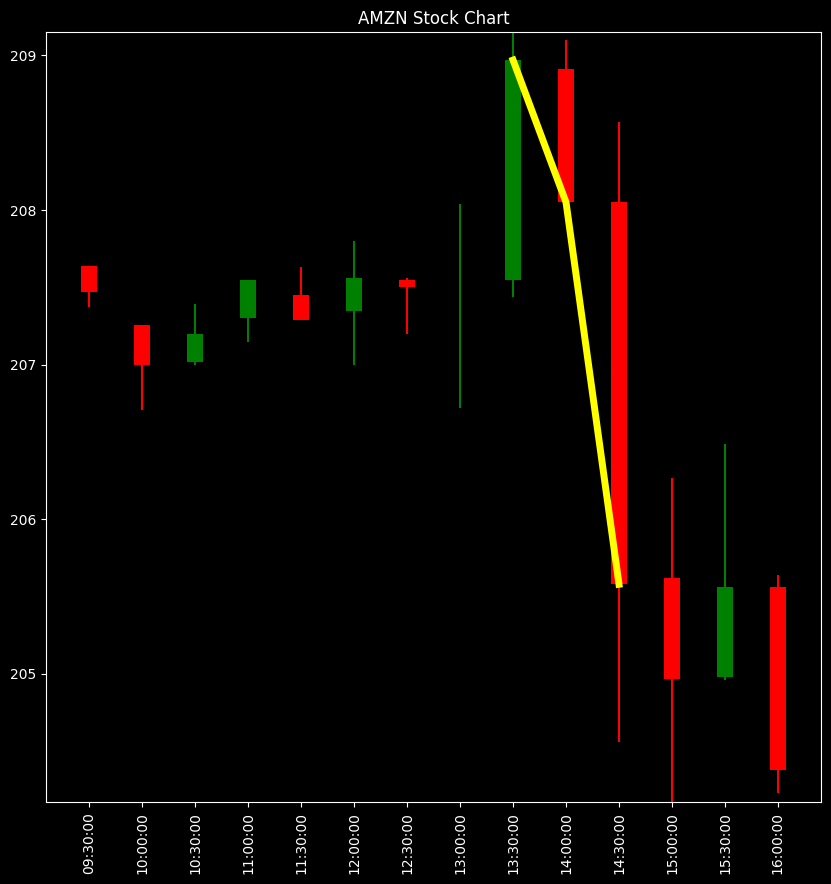

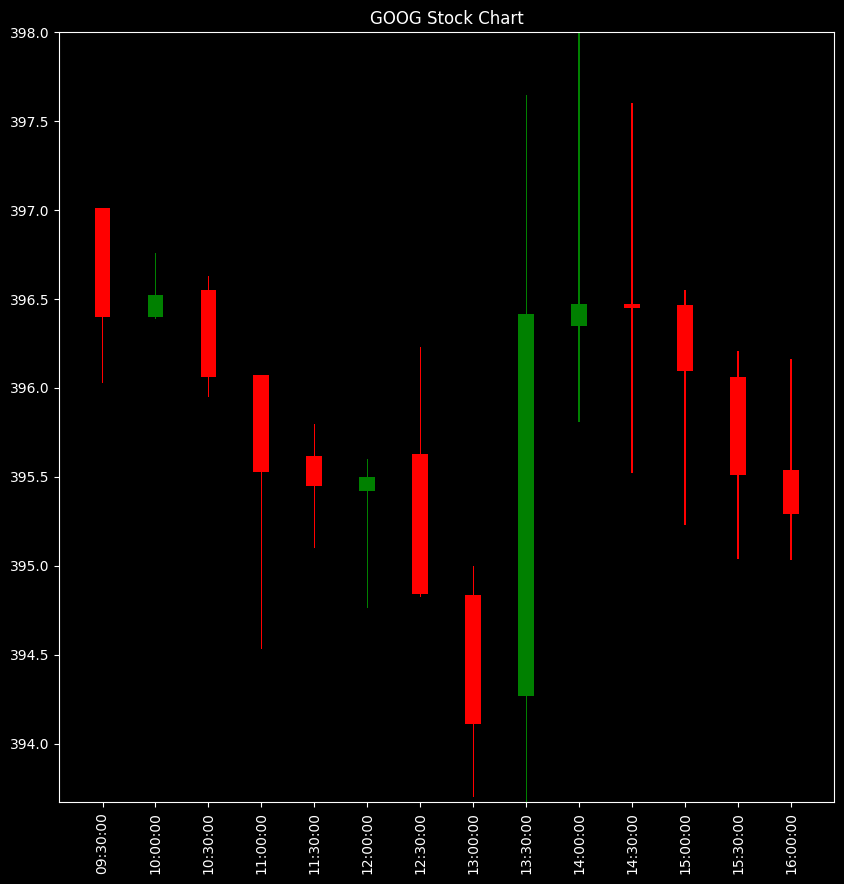

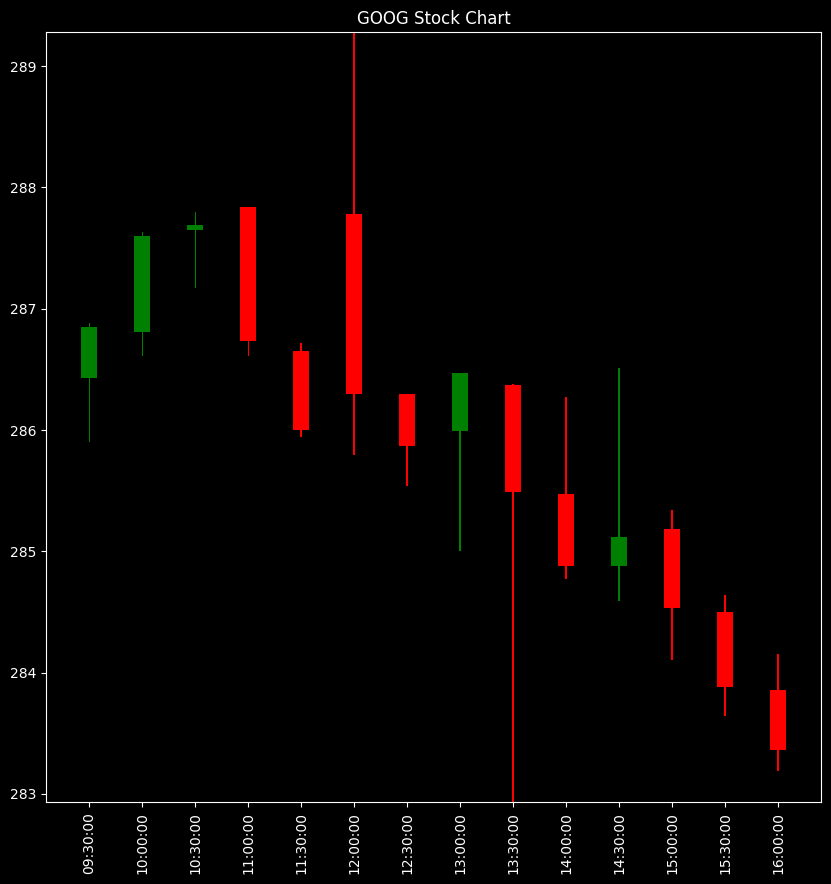

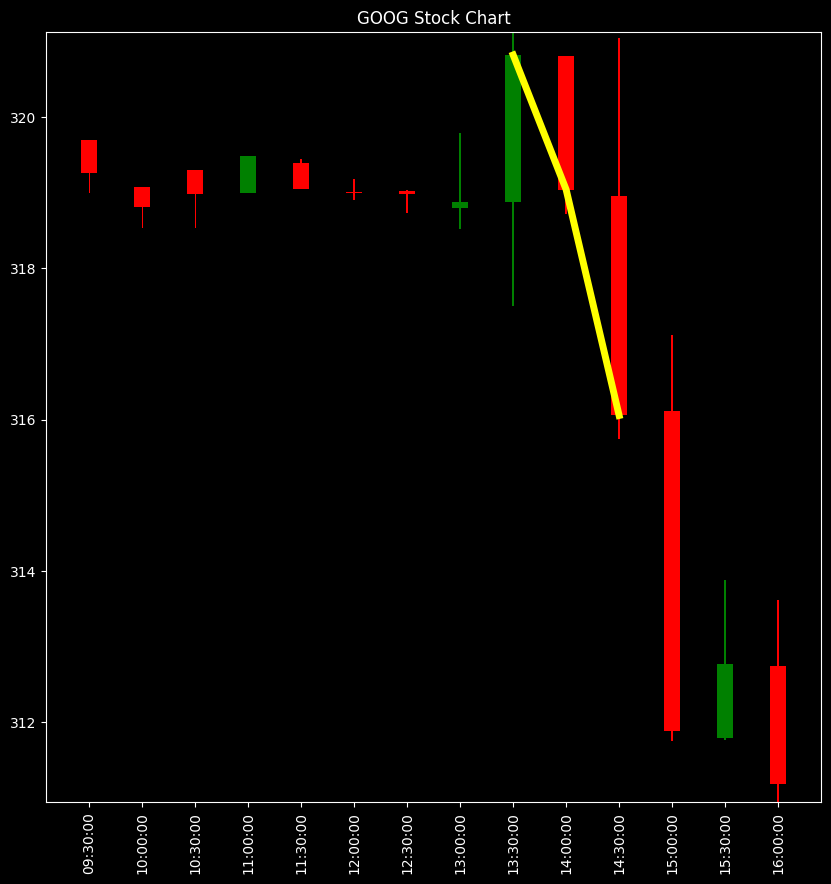

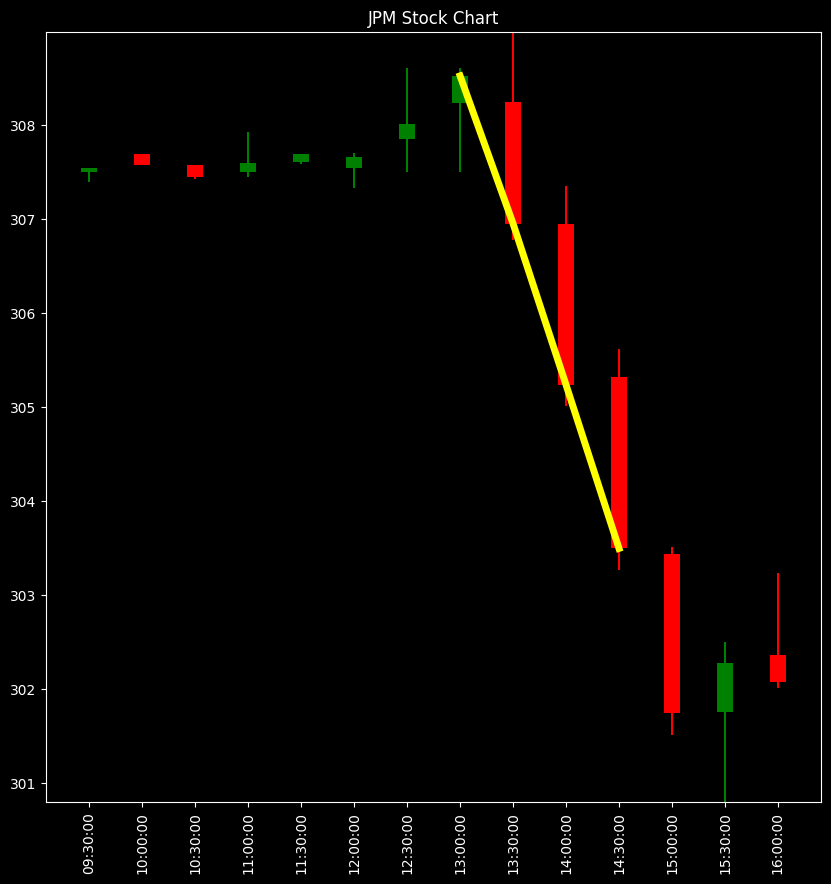

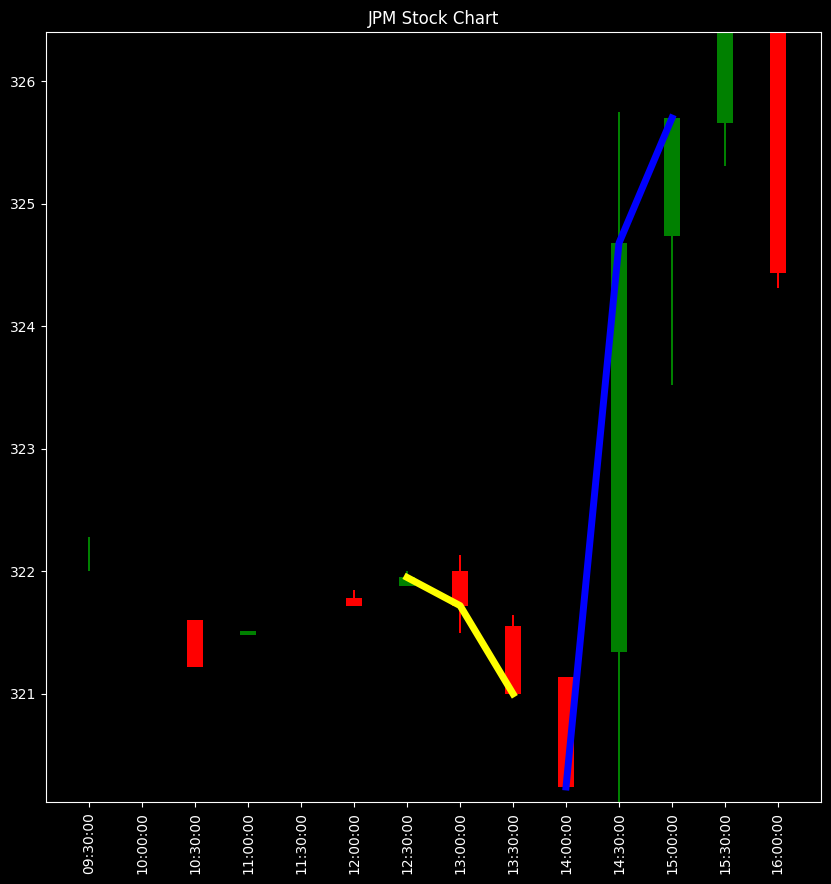

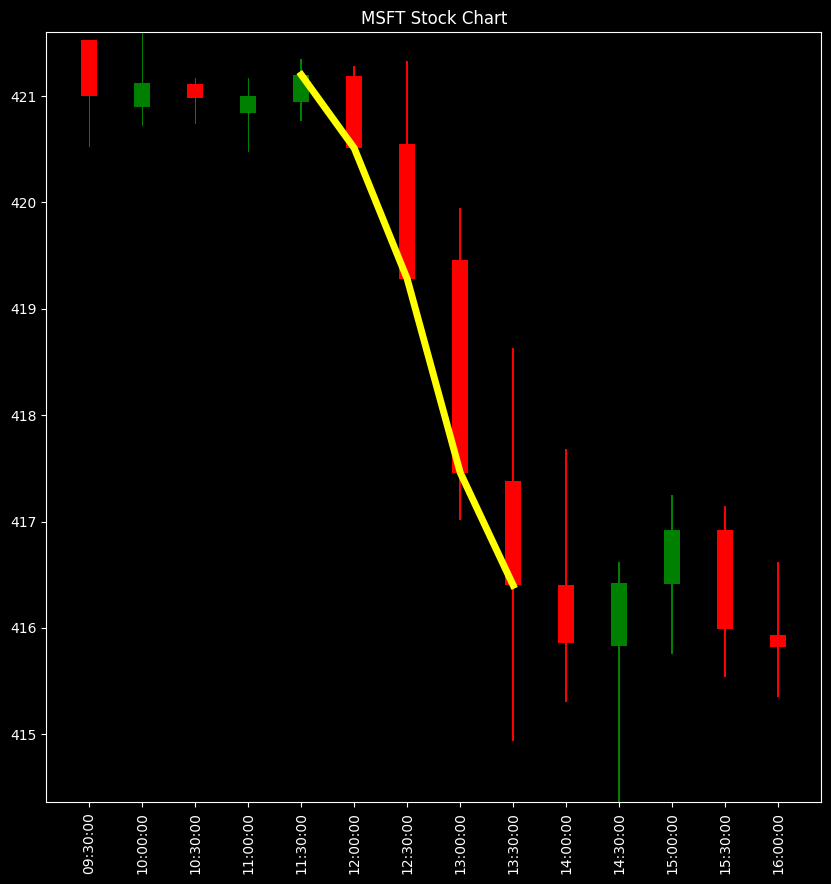

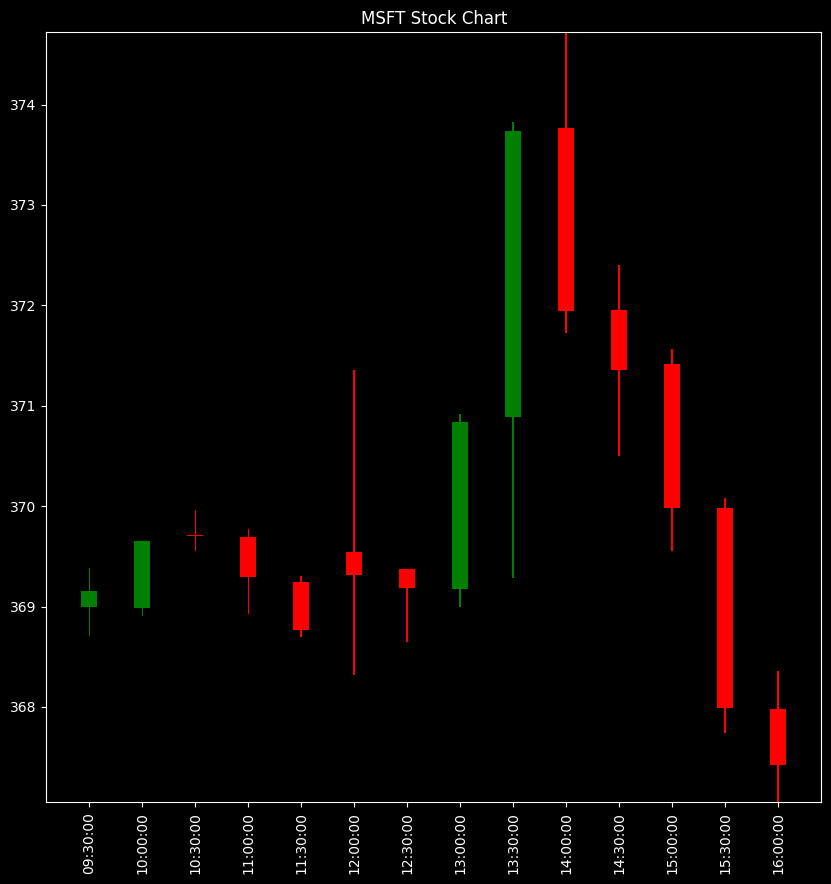

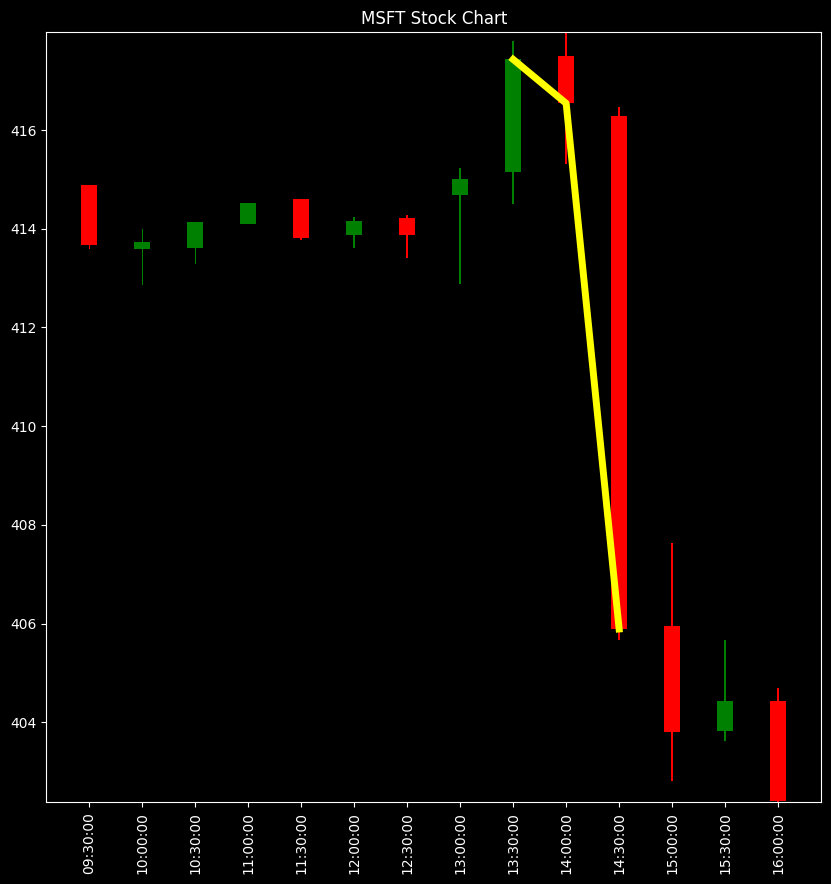

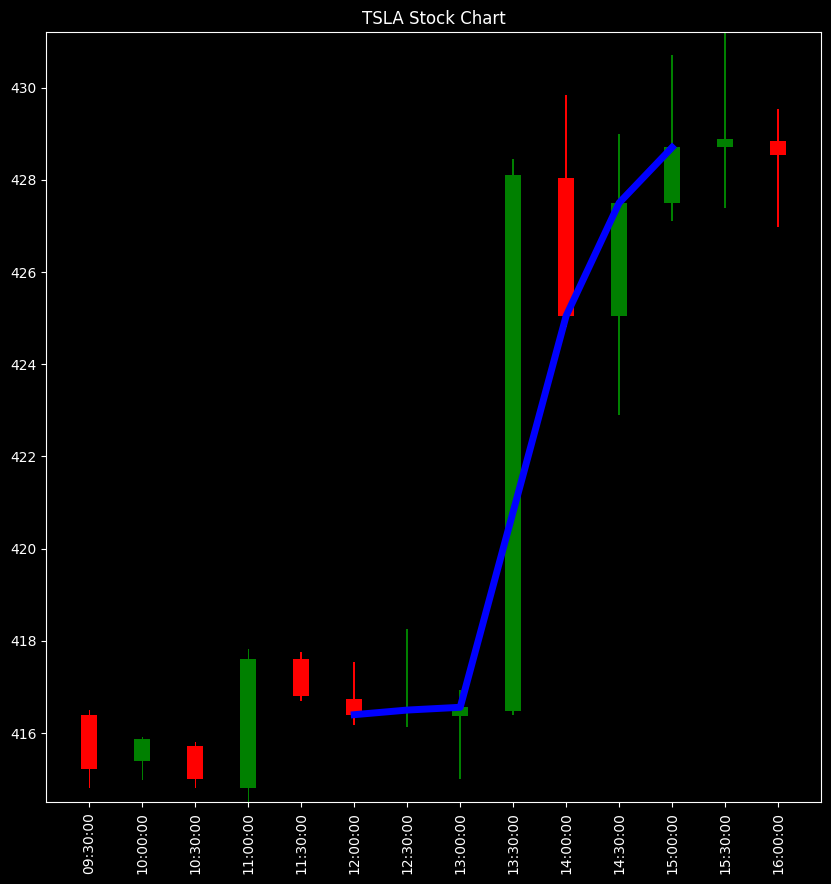

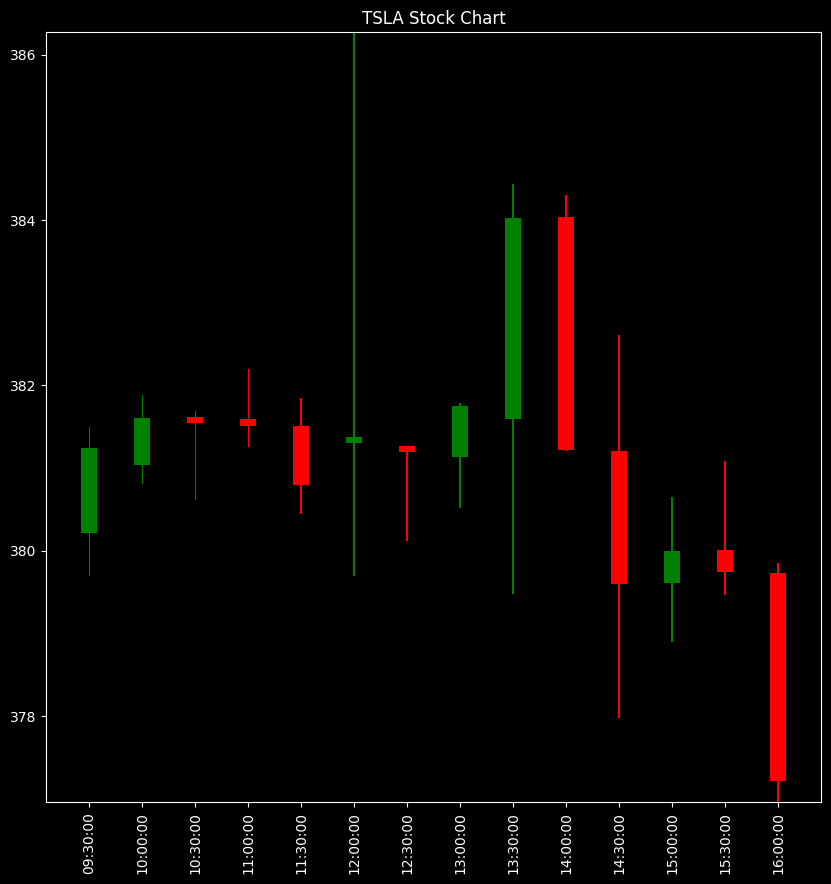

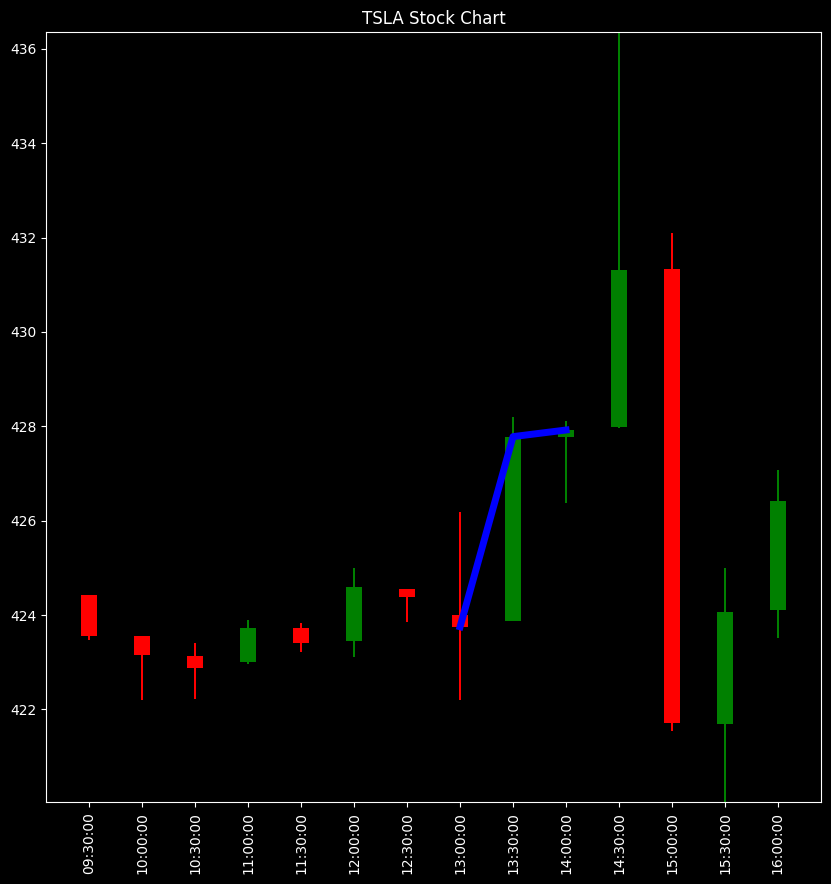

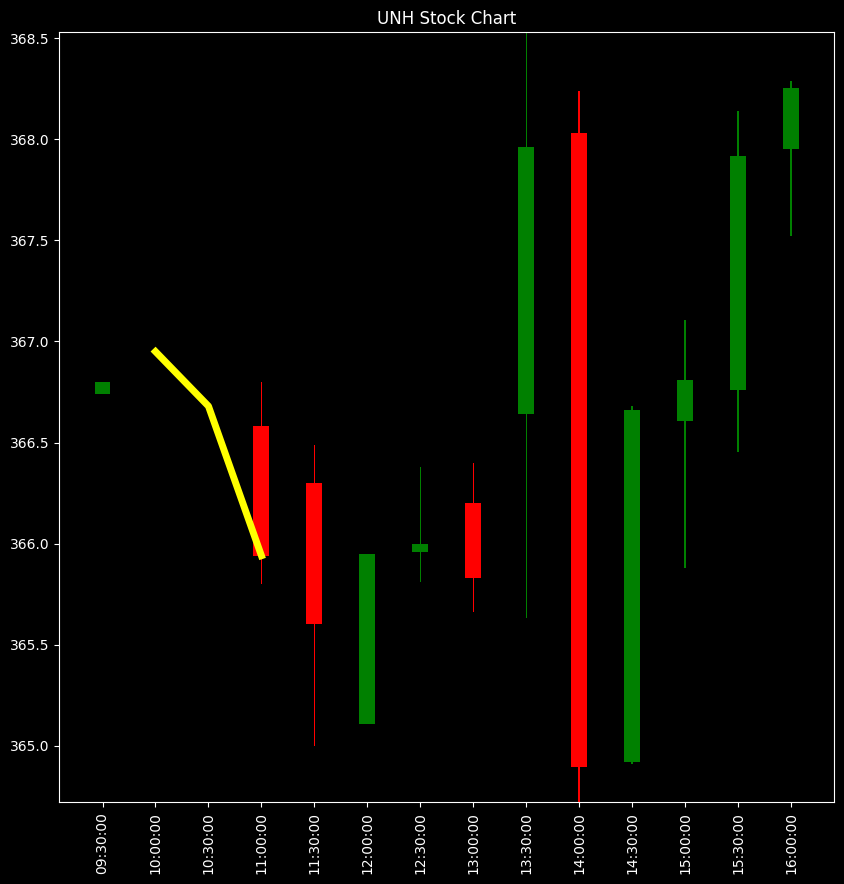

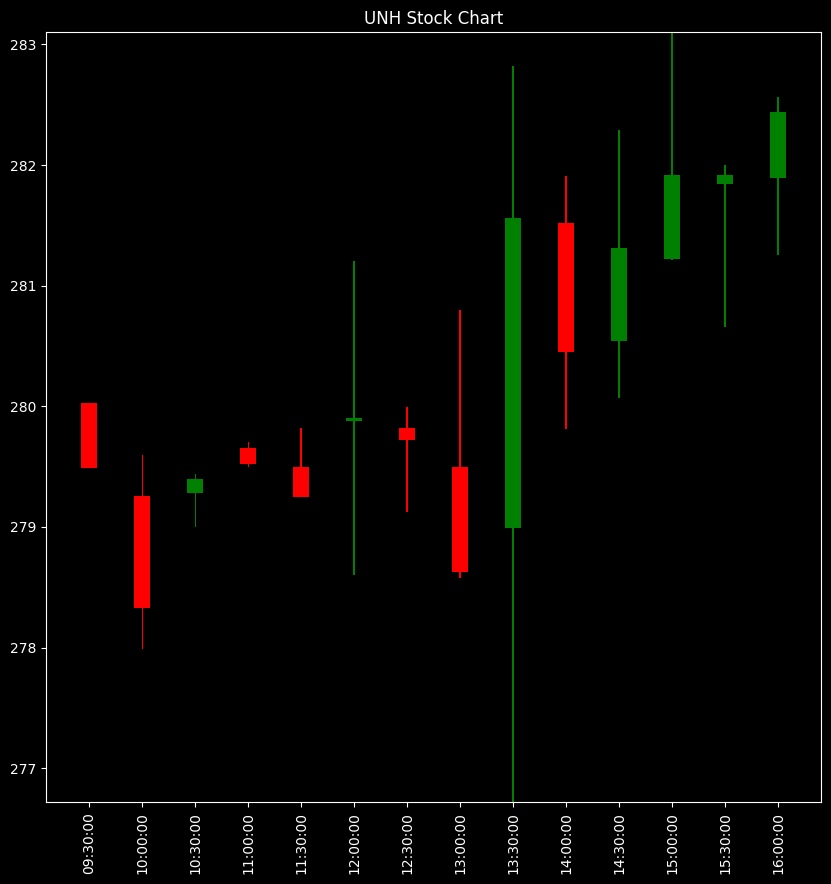

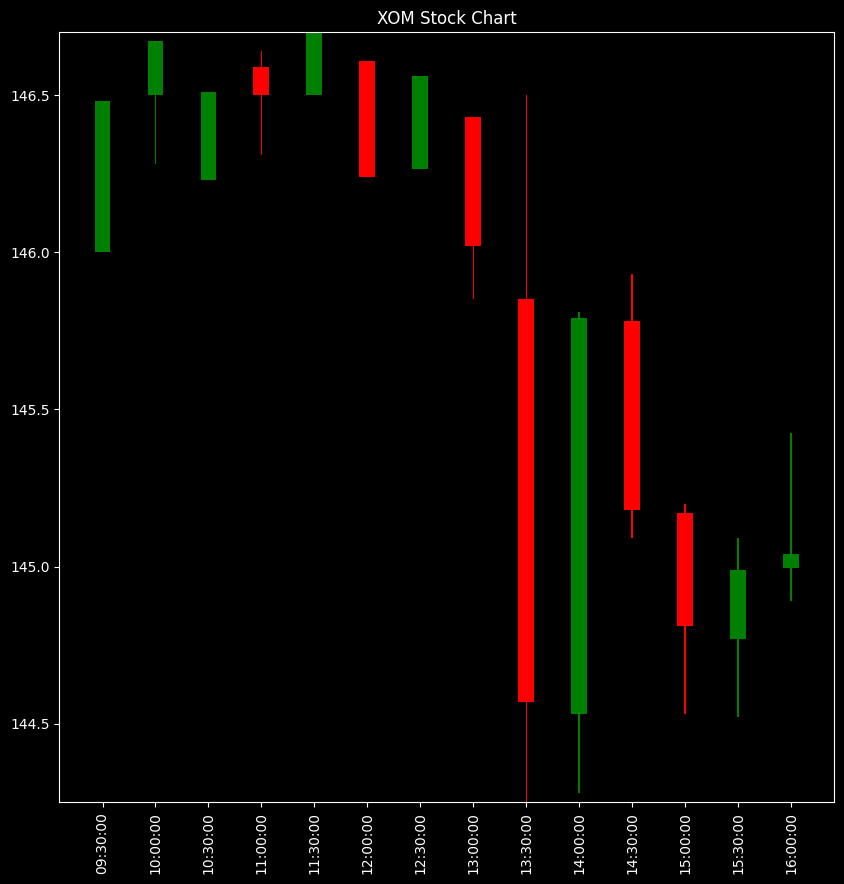

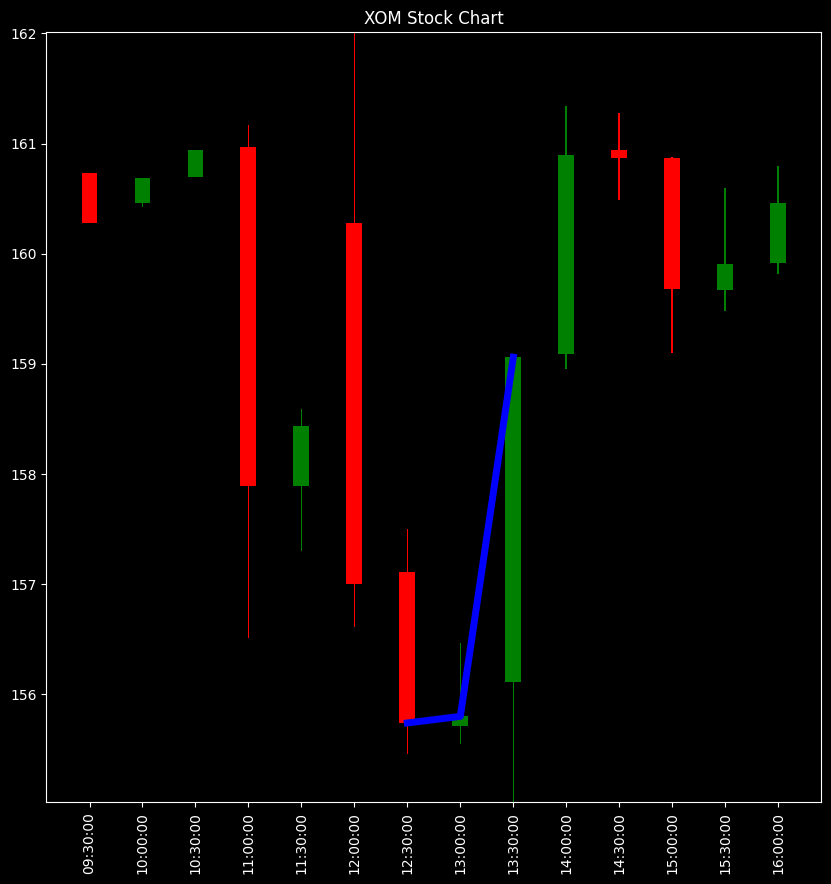

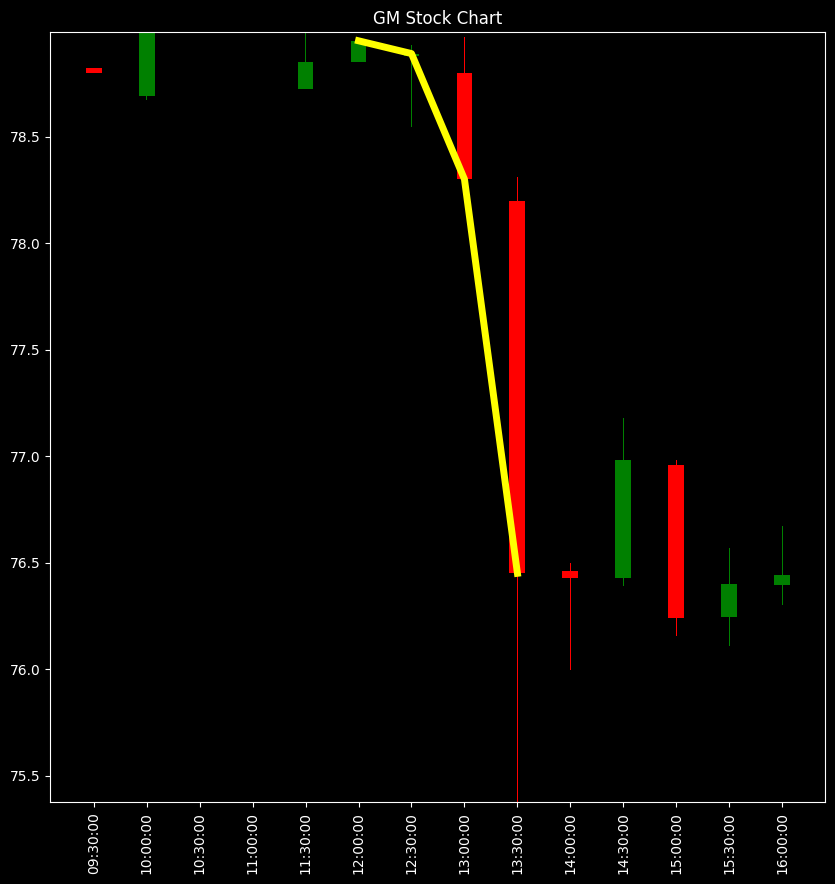

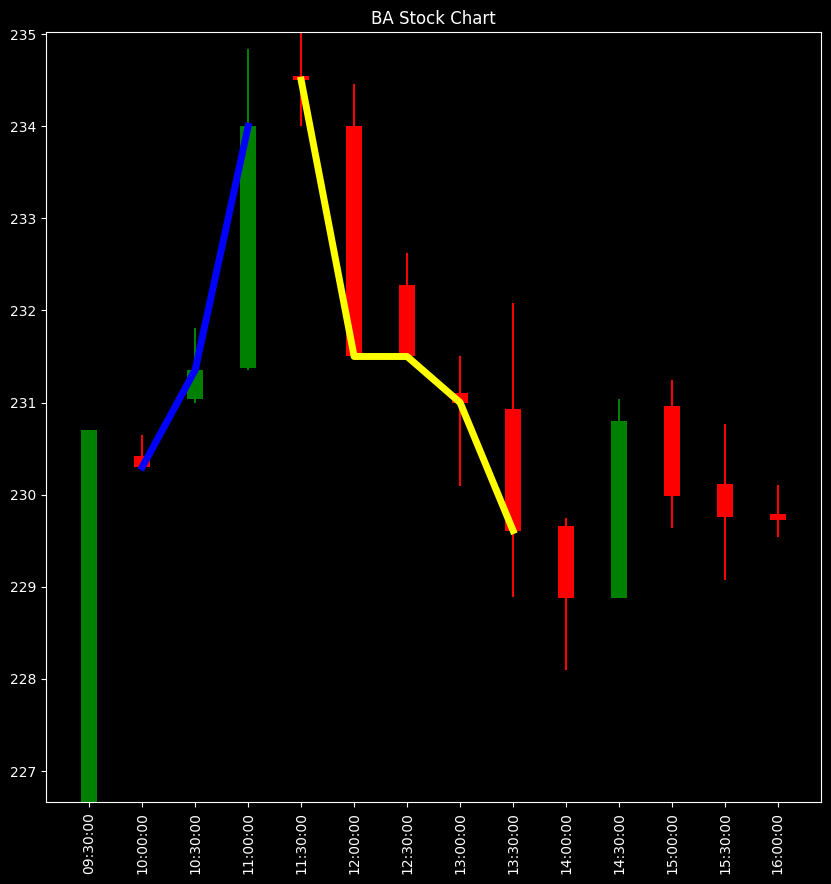

In [11]:
symbol_data = load_all_symbol_data()
training_data_X = []
training_data_Y = []

feature_cols = ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'day_of_week', 'hour', 'minute']
trend_cols   = ['up_trend', 'down_trend', 'no_trend']

for symbol, (df, series_unique_dates) in symbol_data.items():
    for i,day_i in enumerate(series_unique_dates):
        #dayday = df.where(df.date == day)
        # day = df.copy(deep=True)
        day = df[df.date == day_i].copy(deep=True)
        day.sort_values(by = 'time',ascending = True,inplace=True)
             
        up,down = consecutive_trend_search(day)
        day['up_trend'] = up
        day['down_trend'] = down
        day['no_trend'] = np.logical_not(day['up_trend'] | day['down_trend'])
        day.no_trend = day.no_trend.astype(int)
        #print(day)
        
        if i % 30 == 0: plot(day)
        
        x = np.zeros(len(day.date))
        x_i=0
        
        for ticker_i in range(day.index[0],len(day.date)+day.index[0]):
            sample = day.copy(deep=True)
            x[x_i]=1
            x_i+=1
            sample.open = sample.open*x
            sample.high = sample.high*x
            sample.low = sample.low*x
            sample.close = sample.close*x
            sample.volume = sample.volume*x
            sample.trade_count = sample.trade_count*x
            sample.vwap = sample.vwap*x
            sample.up_trend = sample.up_trend*x
            sample.down_trend = sample.down_trend*x
            sample.no_trend = sample.no_trend*x
            #print(sample)
            #plot(sample)

            #normalize
            first_close = sample.close[sample.close != 0].iloc[0]
            sample[['open','high','low','close','vwap']] = sample[['open','high','low','close','vwap']] / first_close

        training_data_X.append(day[feature_cols].values)
        training_data_Y.append(day[trend_cols].values)
            
        #if i == 0:break
        #else:i+=1


In [ ]:


X = np.array(training_data_X)
y = np.array(training_data_Y)
# print('X shape:', X.shape)
# print('y shape:', y.shape)
# print(y)


X shape: (439, 14, 10)
y shape: (439, 14, 3)
[[[0 0 1]
  [0 0 1]
  [0 0 1]
  ...
  [0 0 1]
  [0 0 1]
  [0 0 1]]

 [[0 0 1]
  [0 0 1]
  [0 0 1]
  ...
  [0 0 1]
  [0 0 1]
  [0 0 1]]

 [[0 0 1]
  [0 0 1]
  [1 0 0]
  ...
  [0 0 1]
  [0 0 1]
  [0 0 1]]

 ...

 [[0 0 1]
  [0 0 1]
  [0 0 1]
  ...
  [0 0 1]
  [0 0 1]
  [0 0 1]]

 [[0 0 1]
  [0 0 1]
  [0 0 1]
  ...
  [0 0 1]
  [0 0 1]
  [0 0 1]]

 [[0 0 1]
  [0 0 1]
  [0 0 1]
  ...
  [0 0 1]
  [0 0 1]
  [0 0 1]]]
